In [8]:
# 라이브러리 가져오기
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, ReLU
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
import numpy as np
import matplotlib.pyplot as plt

In [9]:
# MNIST 데이터 로드
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# 데이터 정규화
X_train = X_train.reshape(-1,28,28,1)/255.0
X_test = X_test.reshape(-1,28,28,1)/ 255.0

# 레이블 원-핫 인코딩
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [14]:
# CNN 구조 설계 (합성곱,풀링,평탄화,Dense)
model = Sequential()

# 합성곱층 (Convolution)
model.add(Conv2D(32,kernel_size=(3,3),activation='relu',
                 input_shape=(28,28,1)))

# 풀링층(Pooling)
model.add(MaxPooling2D(pool_size=(2,2)))

# 두 번째 합성곱층 및 풀링
model.add(Conv2D(64,kernel_size=(3,3),activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# 평탄화 (Flarren)
model.add(Flatten())

# 완결 연결층 (Fully Connected Layer)
model.add(Dense(128,activation='relu'))

# 출력층 (10개 클래스 분류)
model.add(Dense(10,activation='softmax'))

# 모델 요약
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)                    │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         204,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# 3단계 : 모델 컴파일

model.compile(
    optimizer = 'adam',                # 옵티마이저 (학습속도 향상)
    loss = 'categorical_crossentropy', # 손실 함수  (다중 클래스 분류)
    metrics=['accuracy']               # 평가 지표  (정확도 평가)
)

In [18]:
# 모델 학습

history = model.fit(
    X_train,y_train,
    batch_size=32,        # 배치 크기
    epochs=5,             # 학습 반복 횟수
    validation_split=0.2  # 학습 데이터 중 20%를 검증에 사용
)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 49s 33ms/step - accuracy: 0.9845 - loss: 0.0487 - val_accuracy: 0.9812 - val_loss: 0.0608
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 83s 34ms/step - accuracy: 0.9896 - loss: 0.0341 - val_accuracy: 0.9870 - val_loss: 0.0421
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 82s 34ms/step - accuracy: 0.9932 - loss: 0.0224 - val_accuracy: 0.9879 - val_loss: 0.0423
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 81s 33ms/step - accuracy: 0.9953 - loss: 0.0154 - val_accuracy: 0.9877 - val_loss: 0.0465
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 81s 32ms/step - accuracy: 0.9964 - loss: 0.0117 - val_accuracy: 0.9899 - val_loss: 0.0395


In [19]:
# 모델 평가

test_loss , test_accuracy = model.evaluate(X_test,y_test)

print(f'test data loss : {test_loss}')
print(f'train data loss : {test_accuracy}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9874 - loss: 0.0468
test data loss : 0.03672783076763153
train data loss : 0.9887999892234802


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step


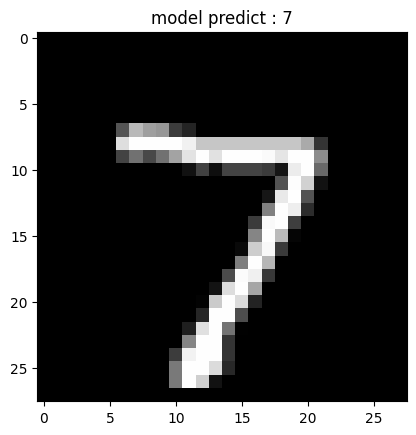

In [20]:
# 테스트 데이터 중 하나 예측
index = 0
sample = X_test[index].reshape(1,28,28,1) # 차원 확장
prediction = model.predict(sample)
prediction_label = np.argmax(prediction)

# 예측 결과 시각화
plt.imshow(X_test[index].reshape(28,28),cmap='gray')
plt.title(f'model predict : {prediction_label}')
plt.show()